# **Primer proyecto de Machine Learning**

Análisis y predicción de un conjunto de datos bancários.
Objetivo de predicción: 

automatizar gráficos de columnas:

## PASO 1. **Imports de librerías, data y crear el data frame:**

In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest

In [190]:
df = pd.read_csv("../data/raw/bank-marketing-campaign-data.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## PASO 1. **Análisis descriptivo**

###  **Comprensión de las variables del proyecto**
1. INFORMACIÓN DEL CLIENTE:
> * ``age.`` Edad del cliente (numérico)
> * ``job.`` Tipo de trabajo (categórico)
> * ``marital.`` Estado civil (categórico)
> * ``education.`` Nivel de educación (categórico)
2. INFORMACIÓN BANCÁRIA DEL CLIENTE:
> * ``default.`` ¿Tiene crédito actualmente? (categórico)
> * ``housing.`` ¿Tiene un préstamo de vivienda? (categórico)
> * ``loan.`` ¿Tiene un préstamo personal? (categórico)
3. INFORMACIÓN DE CONTACTO CON EL CLIENTE DURANTE LA ÚLTIMA CAMPAÑA:
> * ``contact.`` Tipo de comunicación de contacto (categórico)
> * ``month.`` Último mes en el que se le ha contactado (categórico)
> * ``day_of_week.`` Último día en el que se le ha contactado (categórico)
> * ``duration.`` Duración del contacto previo en segundos (numérico)
> * ``campaign.`` Número de contactos realizados durante esta campaña al cliente (numérico)
> * ``pdays.`` Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico)
> * ``previous.`` Número de contactos realizados durante la campaña anterior al cliente (numérico)
> * ``poutcome.`` Resultado de la campaña de marketing anterior (categórico)
4. INDICADORES DE ECONOMÍA SOCIAL:
> * ``emp.var``.rate. Tasa de variación del empleo. Indicador trimestral (numérico)
> * ``cons.price``.idx. Índice de precios al consumidor. Indicador mensual (numérico)
> * ``cons.conf``.idx. Índice de confianza del consumidor. Indicador mensual (numérico)
> * ``euribor3m.`` Tasa EURIBOR 3 meses. Indicador diario (numérico)
> * ``nr.employed`` Número de empleados. Indicador trimestral (numérico)
5. **VARIABLE TARGET**
> * ``y`` El cliente contrata un depósito a largo plazo o no (categórico)


In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### **Comprensión empresarial**

Los depósitos a largo plazo permiten a los bancos retener dinero durante un período de tiempo específico, lo que permite al banco utilizar ese dinero para mejorar sus inversiones. Las campañas de marketing de este producto se basan en llamadas telefónicas. Si un usuario no se encuentra disponible en un momento dado, entonces se le volverá a llamar de nuevo en otro momento.

* **Descripción del problema**

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

* **Objetivo**
Identificar a los clientes con mayor proporcionados en la lista que tienen mayor probabilidad de contratar un depósito a largo plazo.  
Para abordar este problema crearemos un algoritmo de clasificación que ayude a predecir si un cliente contratará o no un depósito a largo plazo.  

**Conclusión:**

Para analizar del conjunto de datos el objetivo será identificar las variables con mayor relación a la información del cliente para así poder buscar cuales son los usuarios potenciales y qué otros datos del conjunto se relacionan más con ellos.



## PASO 2. **Análisis descriptivo**

In [192]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [194]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


**Observaciones:**

> 1. DIMENSIONES DEL DATASET Y TIPOS DE DATO:
> * Contiene 41188 filas y 21 columnas  
> * Los datos que aporta el datset son 10 columnas de tipo numérico (enteros y decimales) y 11 columnas de tipo string (cadenas de texto)  
> * ``dtypes: float64(5), int64(5), object(11)``  

> 2. DESCRIPCIÓN ESTADÍSTICA INICIAL:

#### **Variable Target**

In [195]:
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [196]:
# Media de clientes que ya tienen contratado el servicio
total_yes = df[df['y']=='yes'].value_counts().sum()
mean_yes = (total_yes / len(df) * 100)

# Media de clientes que no han contratado anteriormente un depósito a largo plazo
total_no = df[df['y']=='no'].value_counts().sum()
mean_no = (total_no / len(df) * 100)


In [197]:
mean_no, mean_yes

(np.float64(88.73458288821988), np.float64(11.265417111780131))

**Conclusión:**
> * La mayoría de los clientes no tienen contratado ese servicio y la campaña anterior no obtuvo buenos resultados positivos.
> * El 88.74% de los clientes del data set no contrataron el servicio en la pasaqda campaña, solamente el 11.26% sí lo hizo.

## PASO 3. **Limpieza de datos**

#### **Eliminar duplicados**

In [198]:
df_dupl = df[df.duplicated(subset=df.columns, keep= False)]
df_dupl

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [199]:
# Elimino los duplicados comparando la informacion de las columnas y se conserva 1 fila de la data repetida para no perder la información
df = df.drop_duplicates(subset=df.columns)
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [200]:
# Compruebo si quedan duplicados
df.duplicated().sum()

np.int64(0)

In [201]:
# Compruebo si hay datos nulos (faltantes)
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

**Conclusión de la limpieza de datos:**

> 1. VAOLRES NULOS Y DUPLICADOS:
> * Las columnas no contienen valores nulos y hay 24 filas duplicadas que ya han sido eliminadas.
> * Filas duplicadas: ¿Es posible que existan dos clientes con los mismos datos?  
En el ds no tenemos una columna idewntificadora por cliente en este caso asi que interpreto que las filas duplicadas son distintas llamadas al mismo cliente y elimino los duplicados.

## PASO 4. **Análisis de las variables**

*Decido analizar algunas variables buscando el perfil del cliente qué más ha contratado el depósito a largo plazo.*  
*Para ello analizo algunas columnas*

**Cons.con.idx**

In [202]:
df[df['cons.price.idx']>65].value_counts().sum()

np.int64(41176)

In [203]:
df[df['cons.price.idx']<25].value_counts()

Series([], Name: count, dtype: int64)

#### **Housing**

In [204]:
df['housing'].value_counts()

housing
yes        21571
no         18615
unknown      990
Name: count, dtype: int64

**Observaciones:**

> * Existen 215.571 clientes que ya han contratado un depósito.
> * De lo clientes actuales 19.615 nunca han contratado un depósito a largo plazo
> * Del resto de clientes (990), no sabemos si lo hicieron o no

**Conclusión del gráfico:**
> * Tomo esta variable para ver a qué se dedican las personas que más han contratado un depósito anteriormente
> * Housing indica si el cliente tiene un préstamo de vivienda. Es una vatiable Categórica ¿?

### **ANÁLISIS UNIVARIANTE**

#### **ANÁLISIS DE VARIABLES NUMÉRICO - CATEGÓRICO**

* Inicio con un Gráfico de Gorrelacion para ver qué columnas puedo eliminar
* Para hacer el gráfico de correlación debemos factorizar las variables categóricas para relacionar todas las columnas, ya tengan características numéricas o categóricas

#### **Análisis variables categóricas**

* ``Función: .countplot()`` , analiza bien los datos categóricos dsicretos pero si pasamos vairables numéricas continuas(tiempo, medidas métricas,...) el gráfico no se podrá interpretar bien debido al número de particiones posibles  
Codifico un subconjunto con las columnas categóricas discretas:

In [205]:
categorical_discret_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome"]

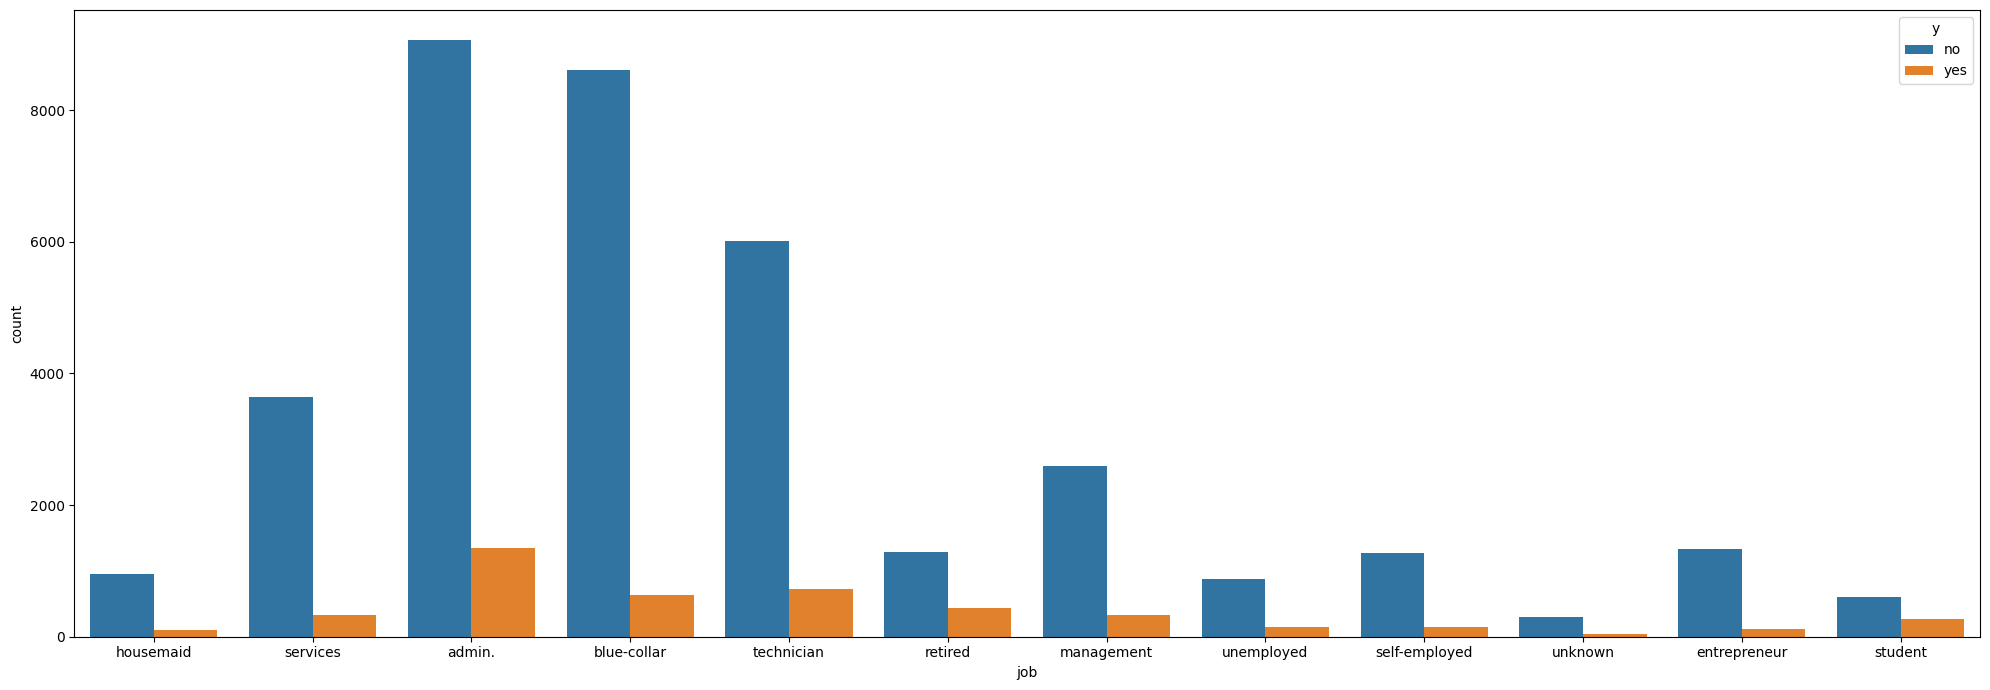

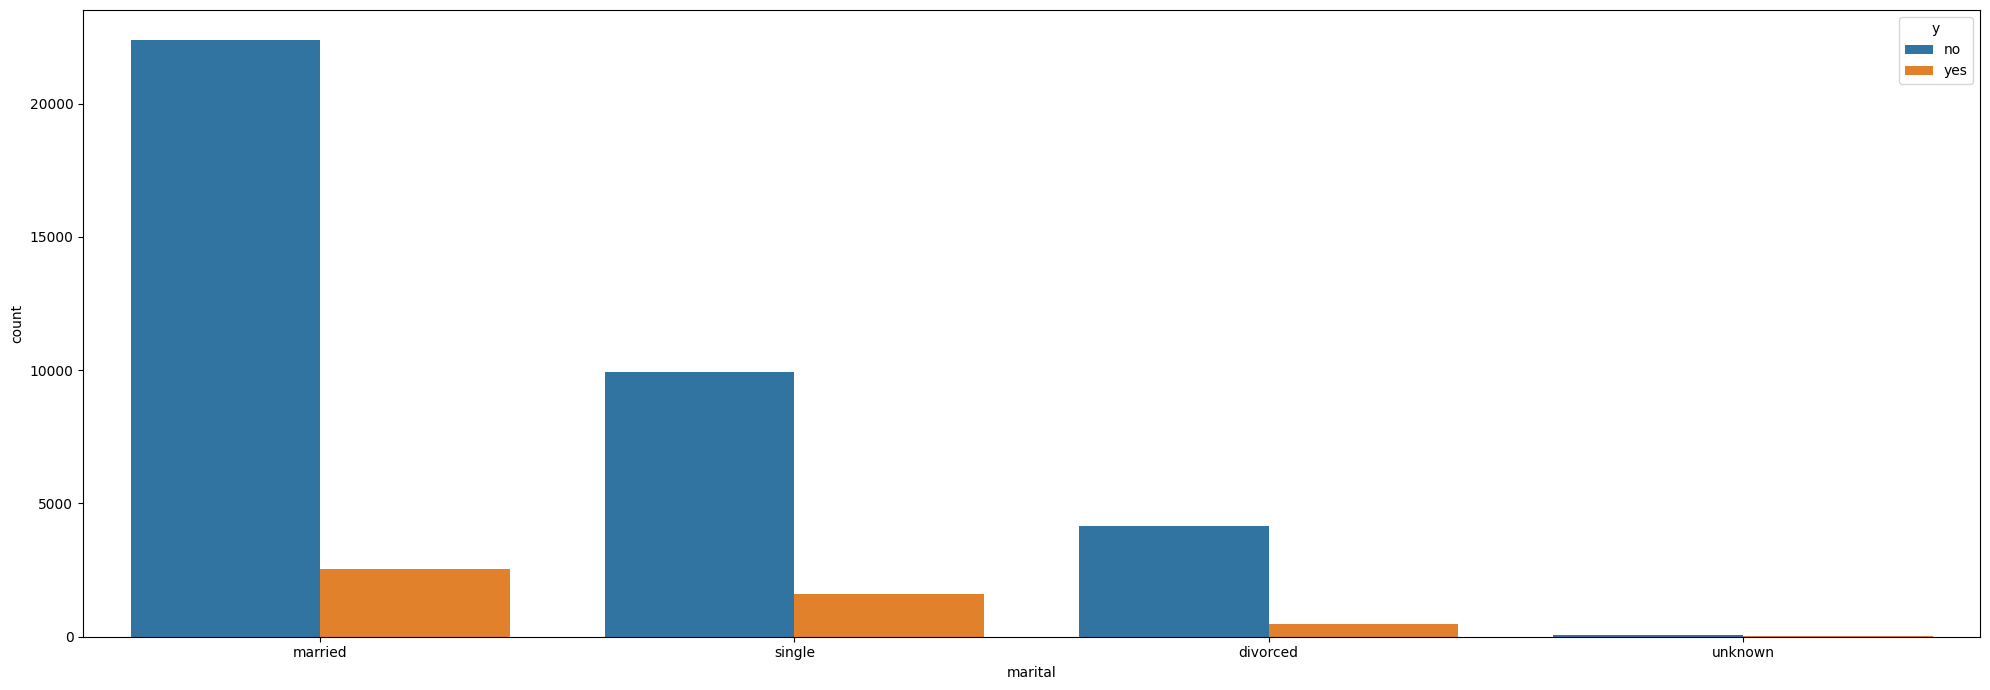

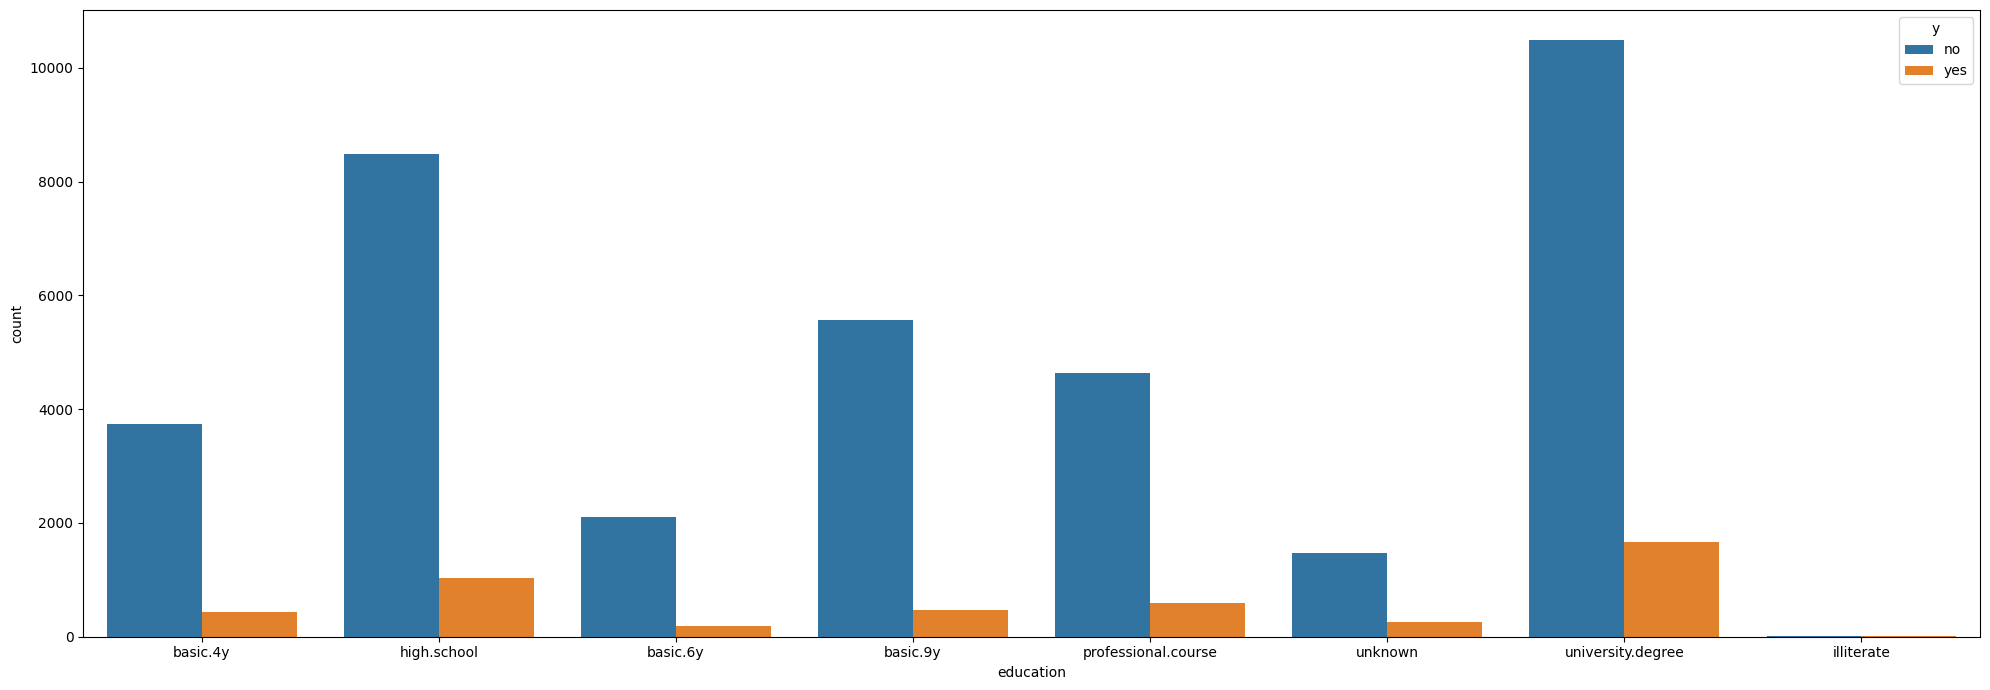

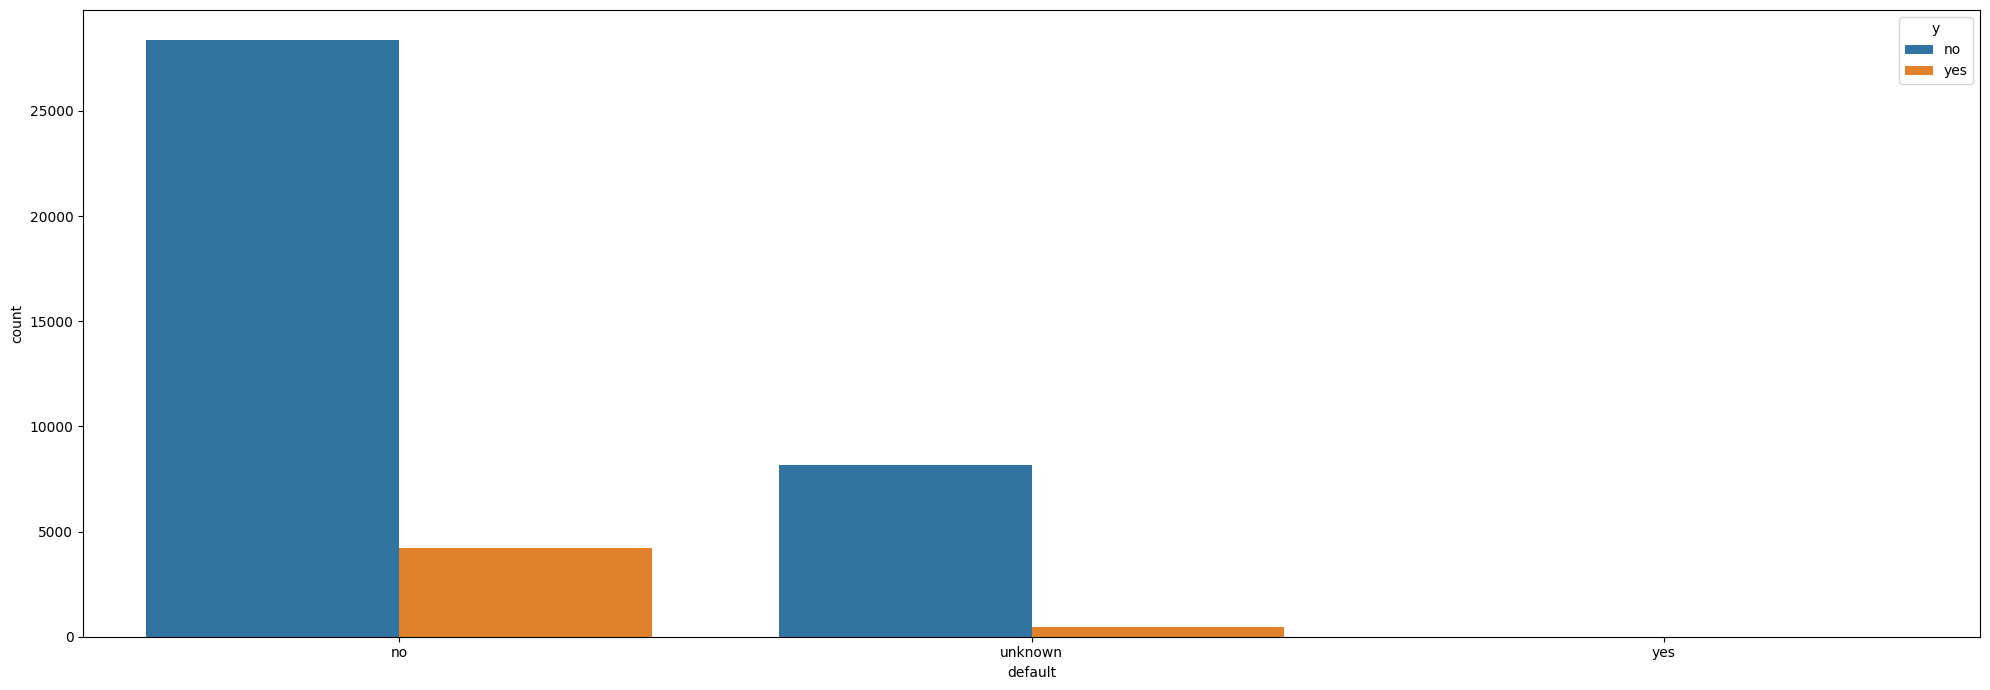

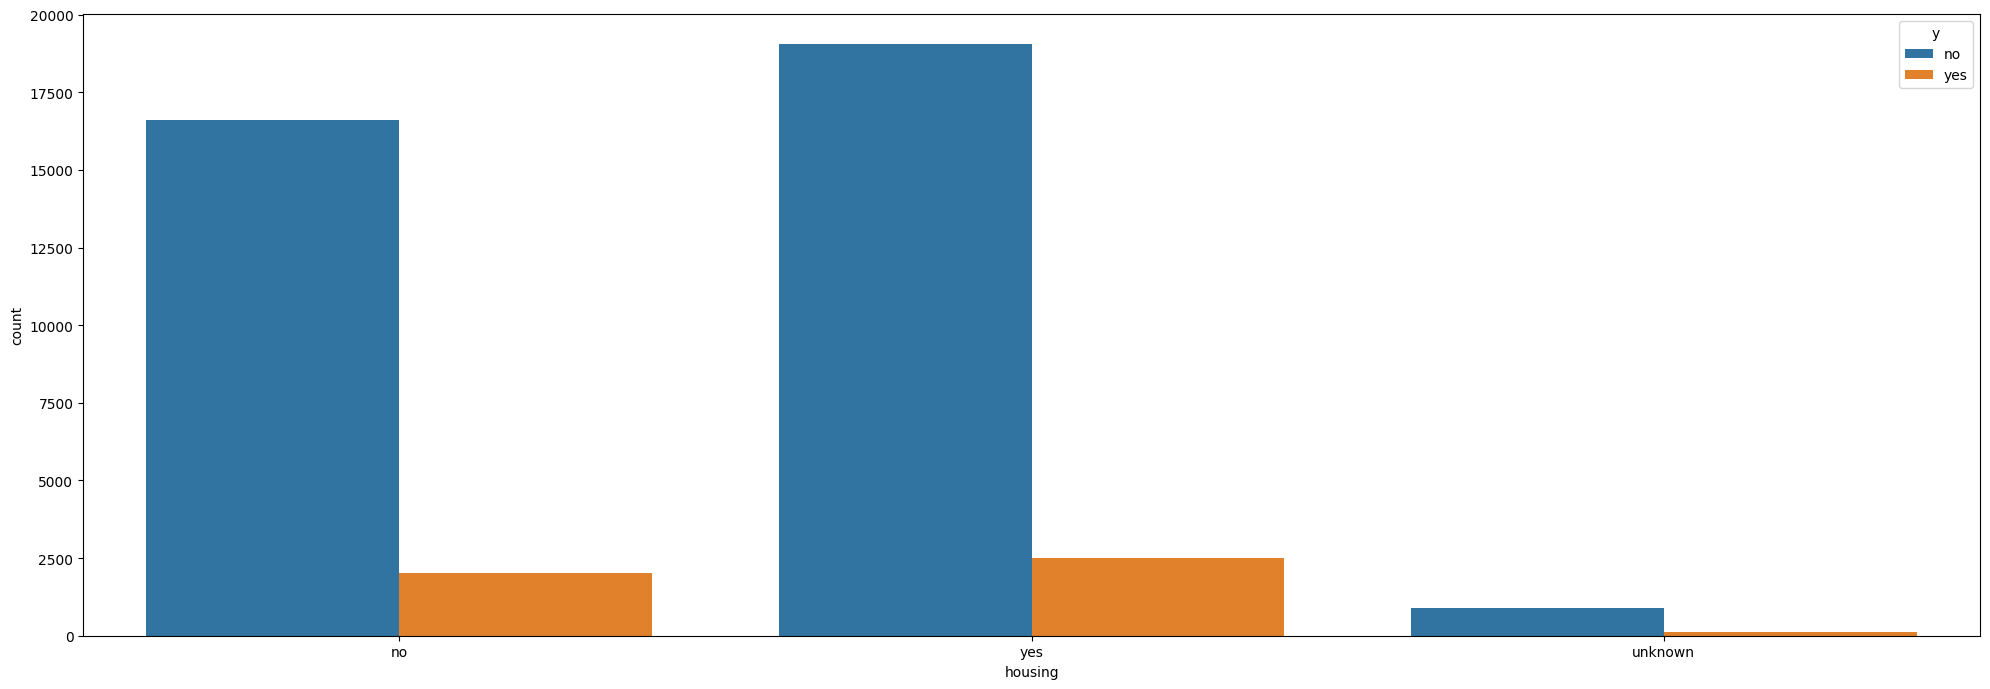

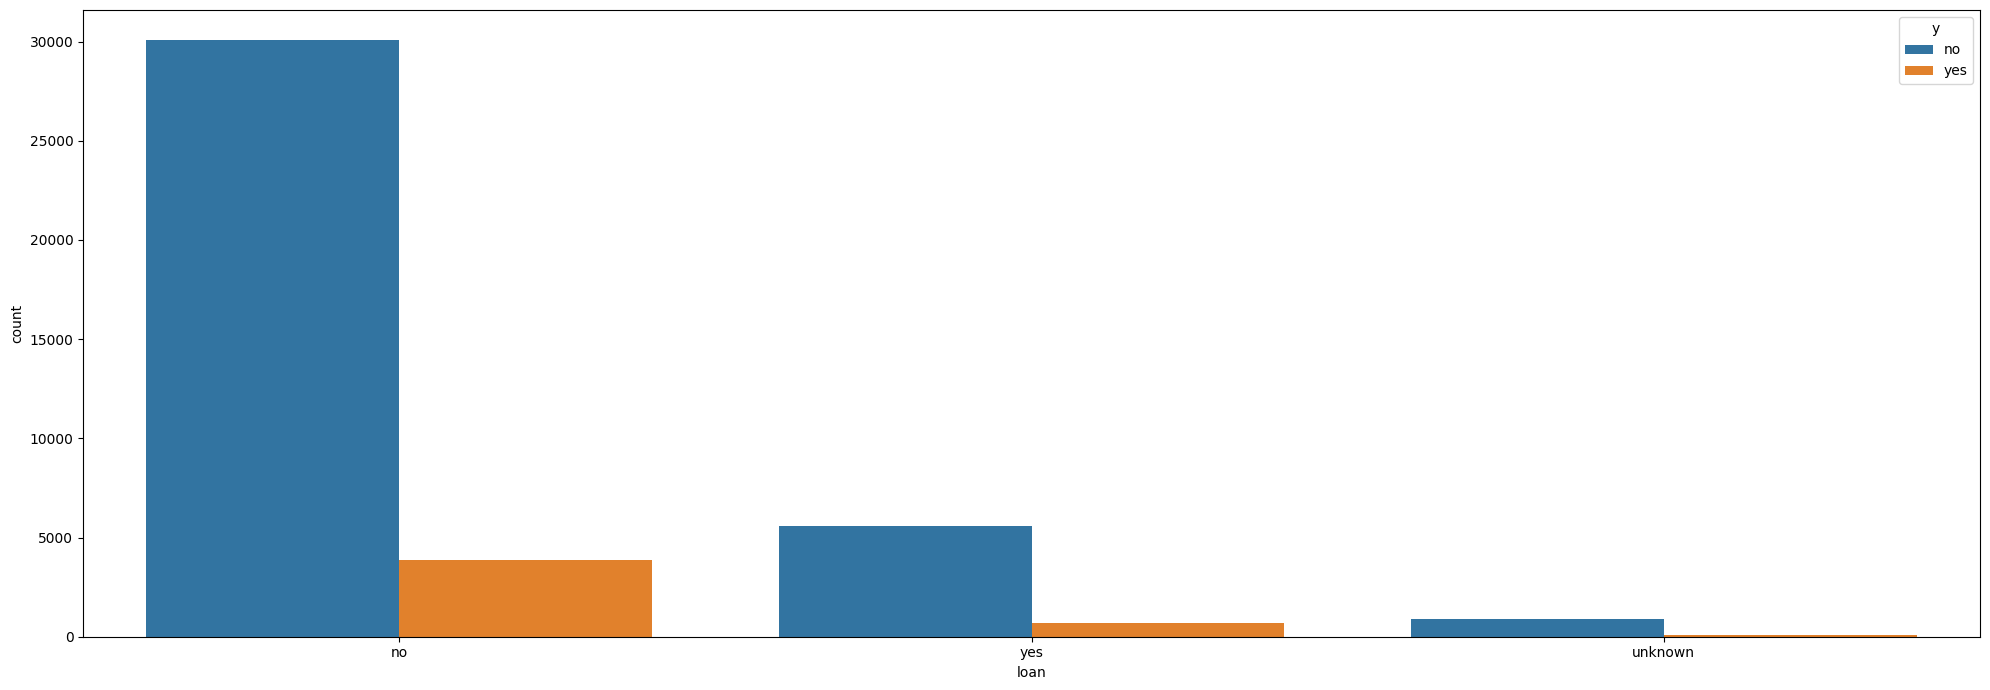

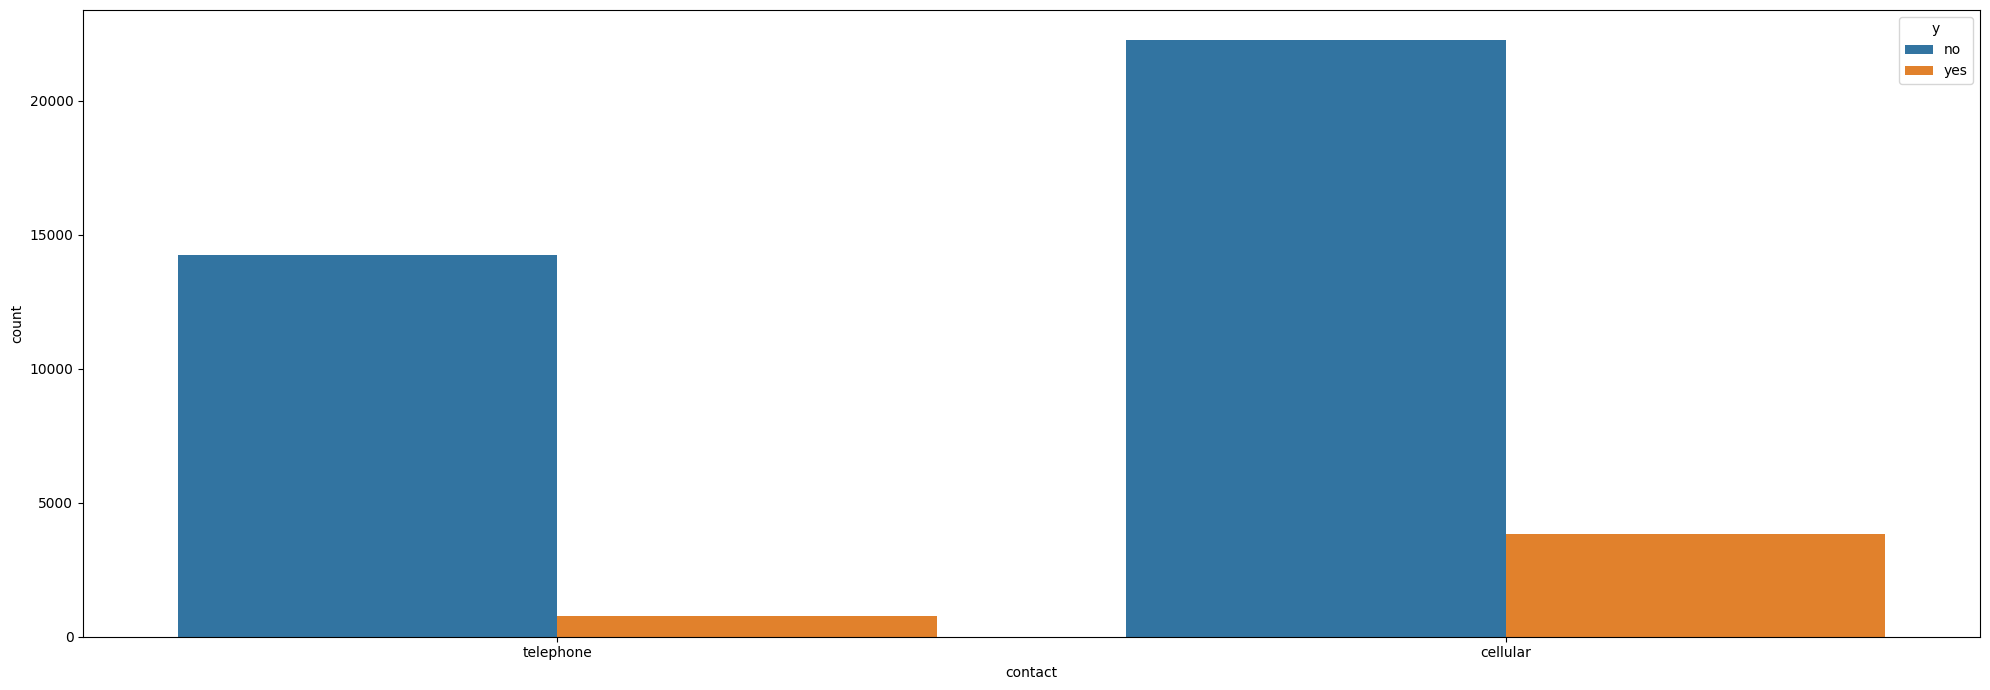

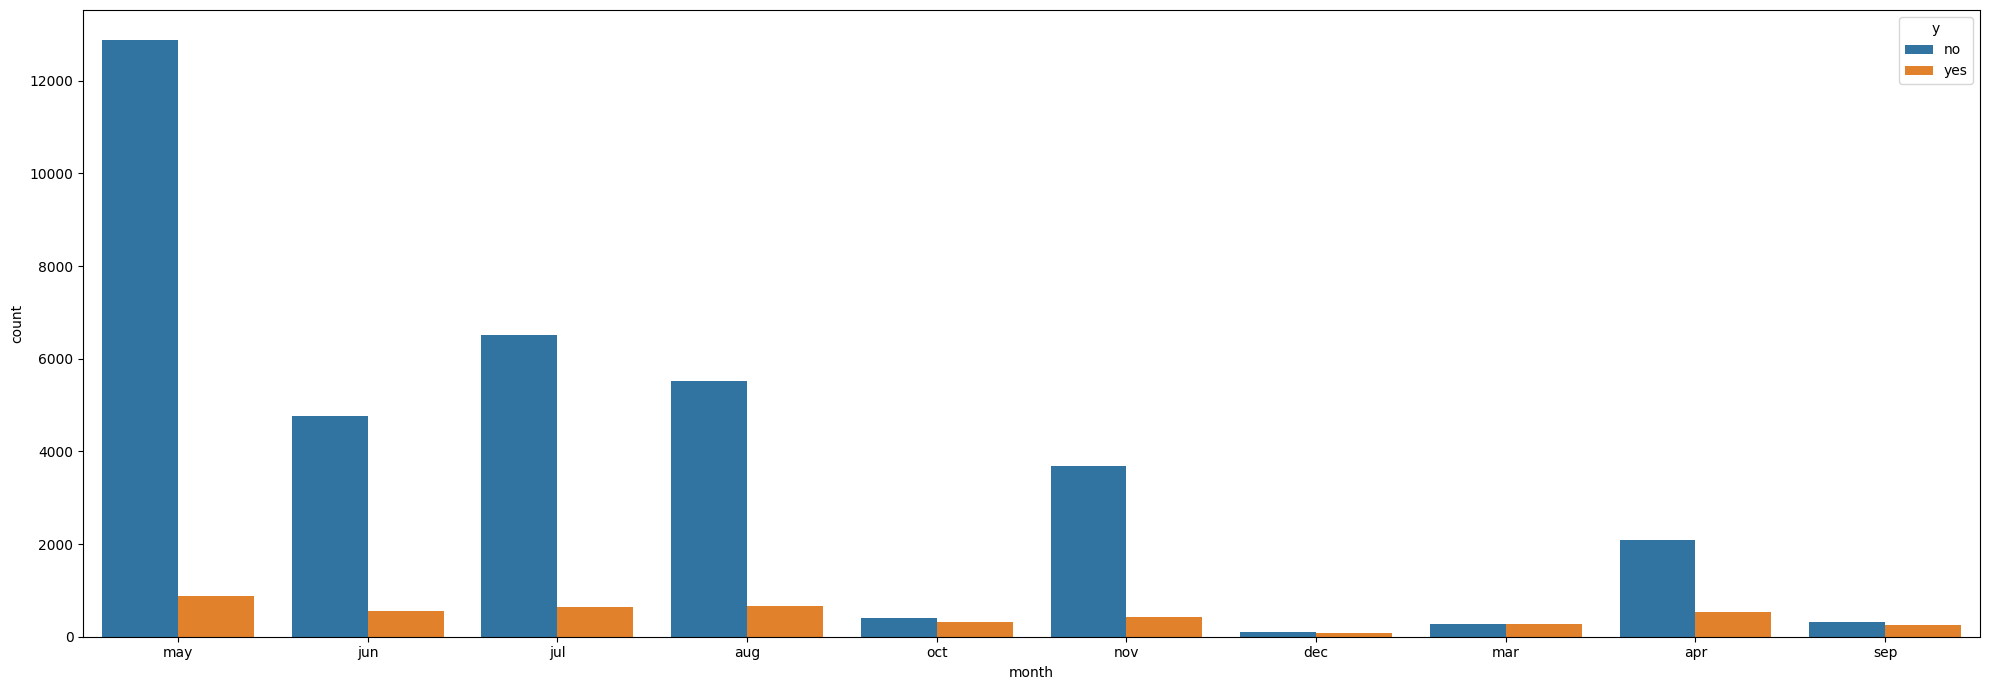

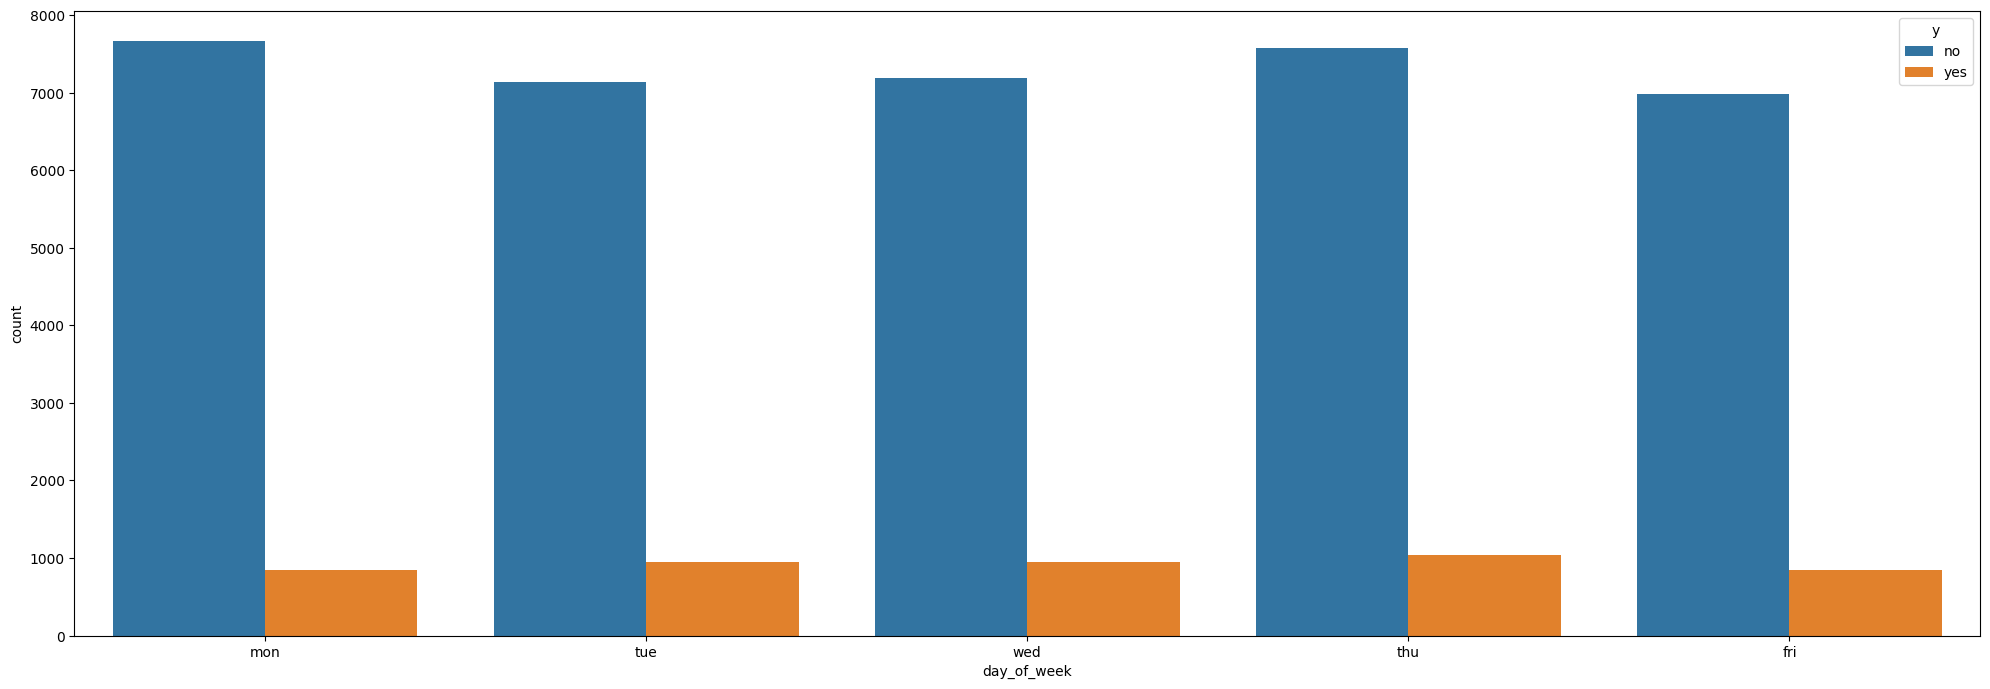

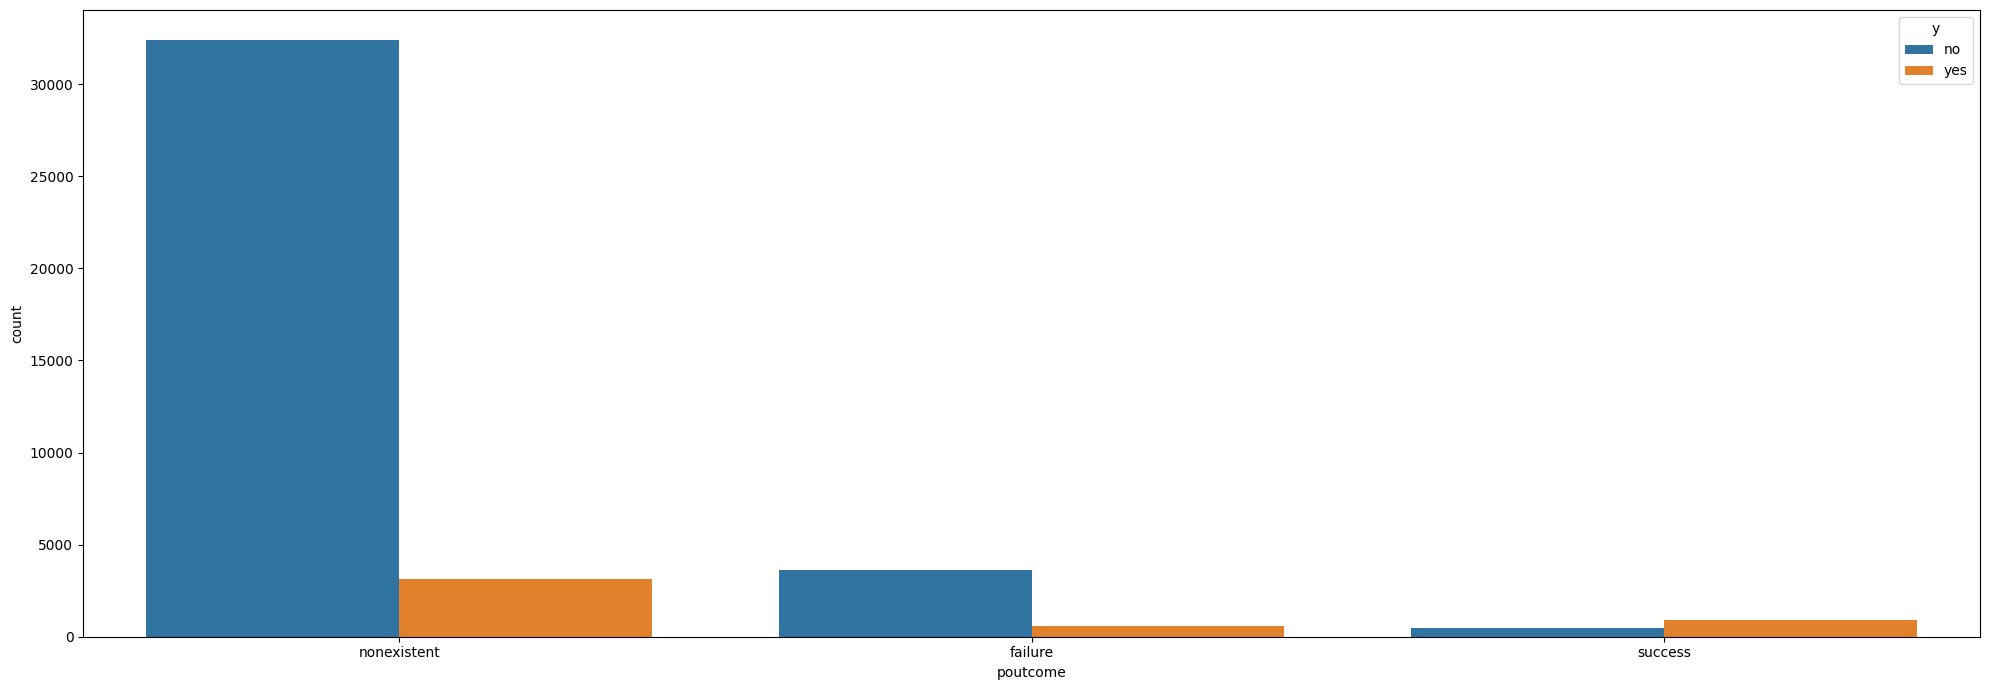

In [206]:
# Bucle para crear gráficos comparando la variable categórica target con el resto de variables 
for column in categorical_discret_cols:
    fig, axis = plt.subplots(figsize=(20, 7))
    sns.countplot(data=df, x=column, hue="y")
    plt.tight_layout()
    plt.show()

mismo proceso apra numeroicas con boxplot

#### **Análisis de variables numéricas (Outliers)**

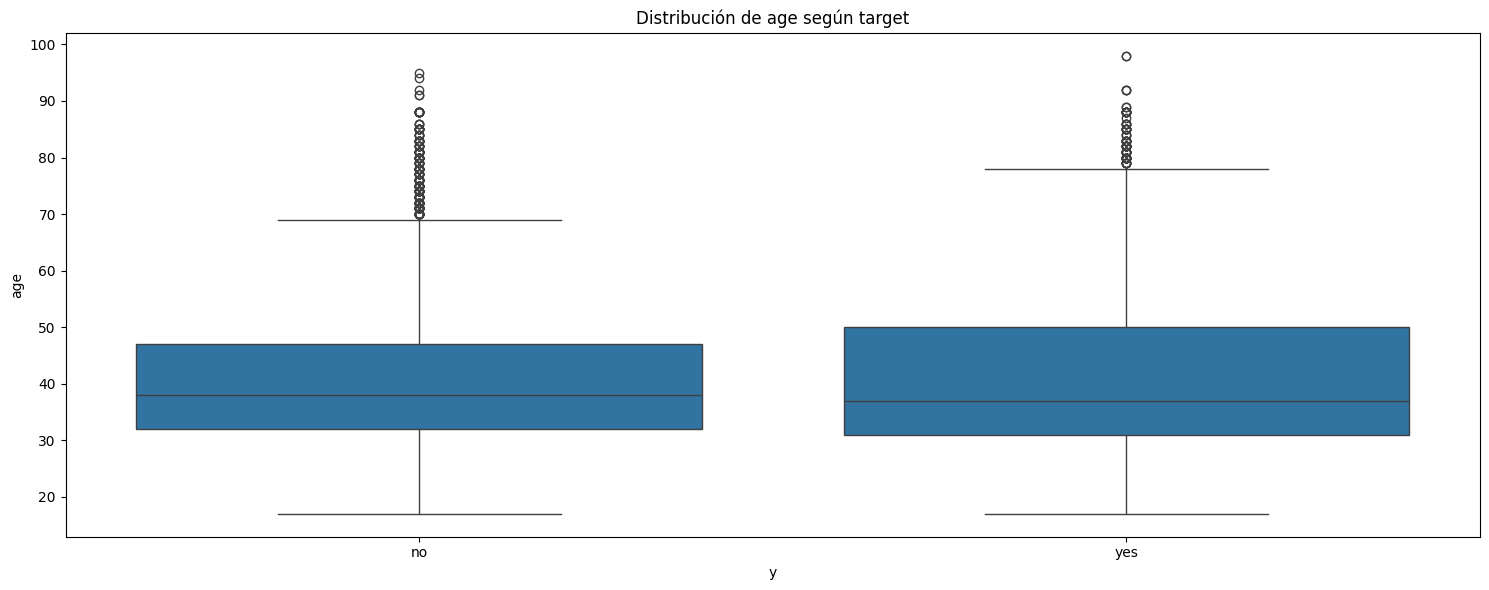

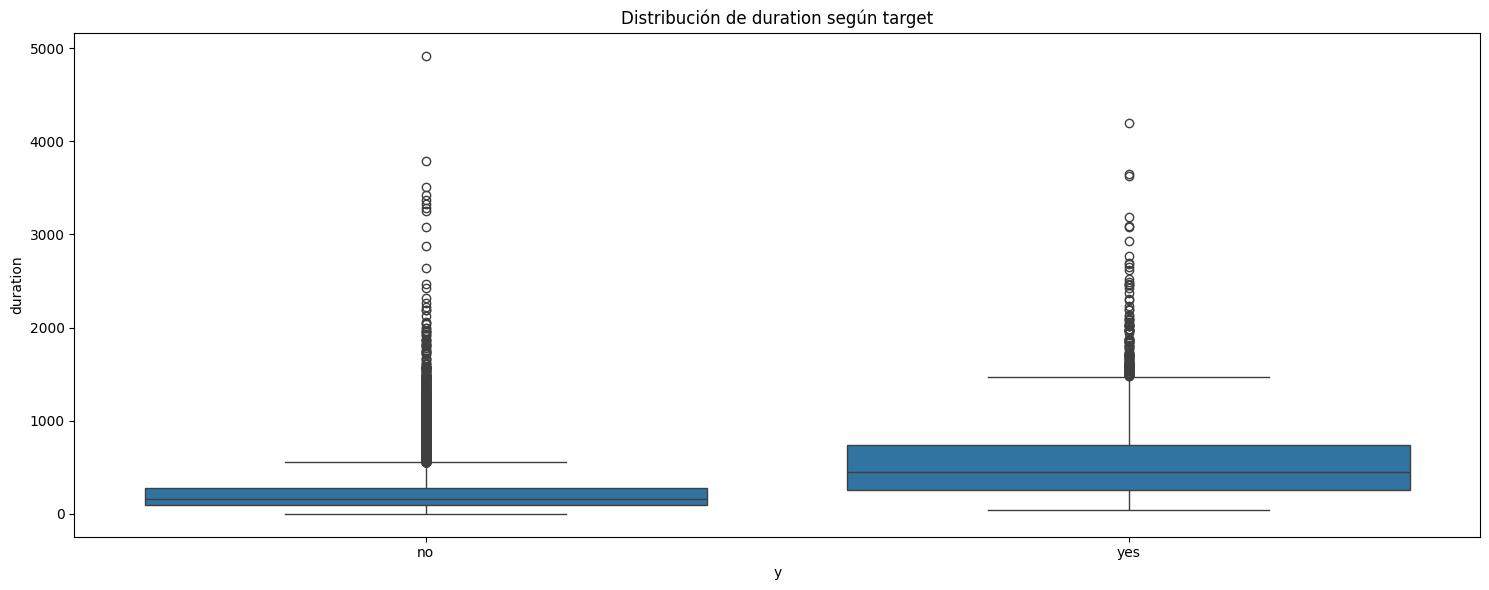

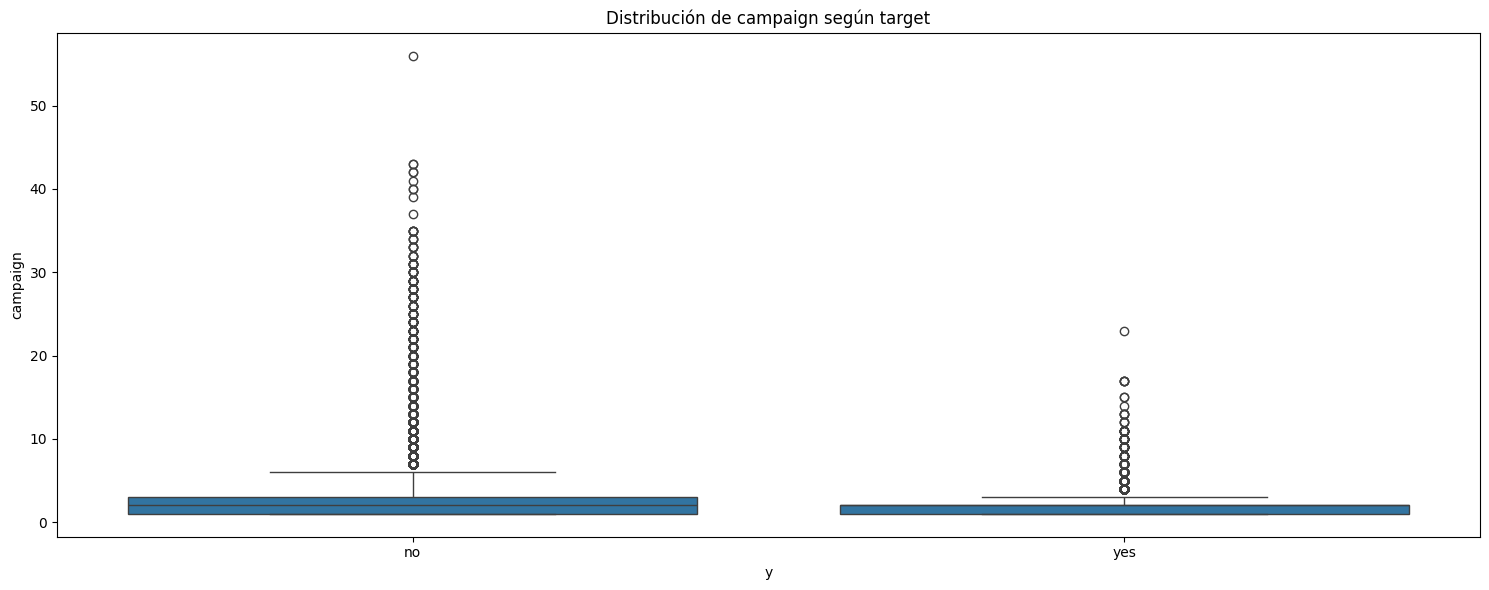

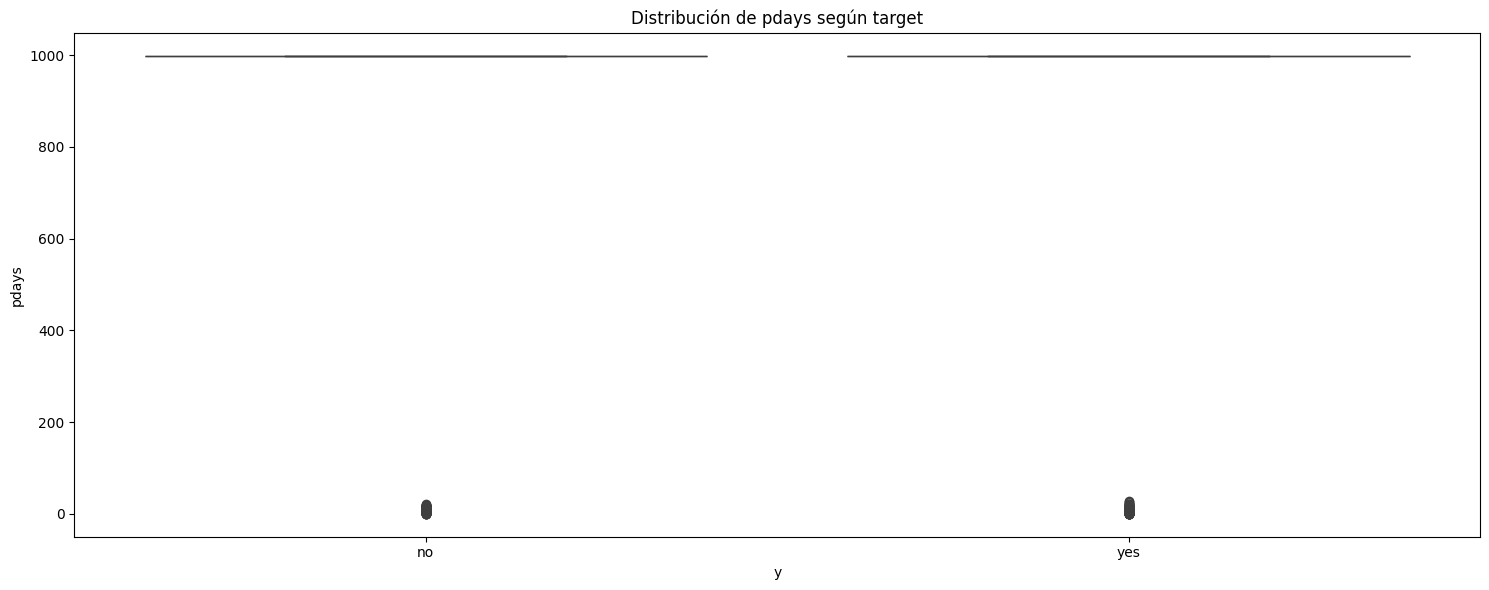

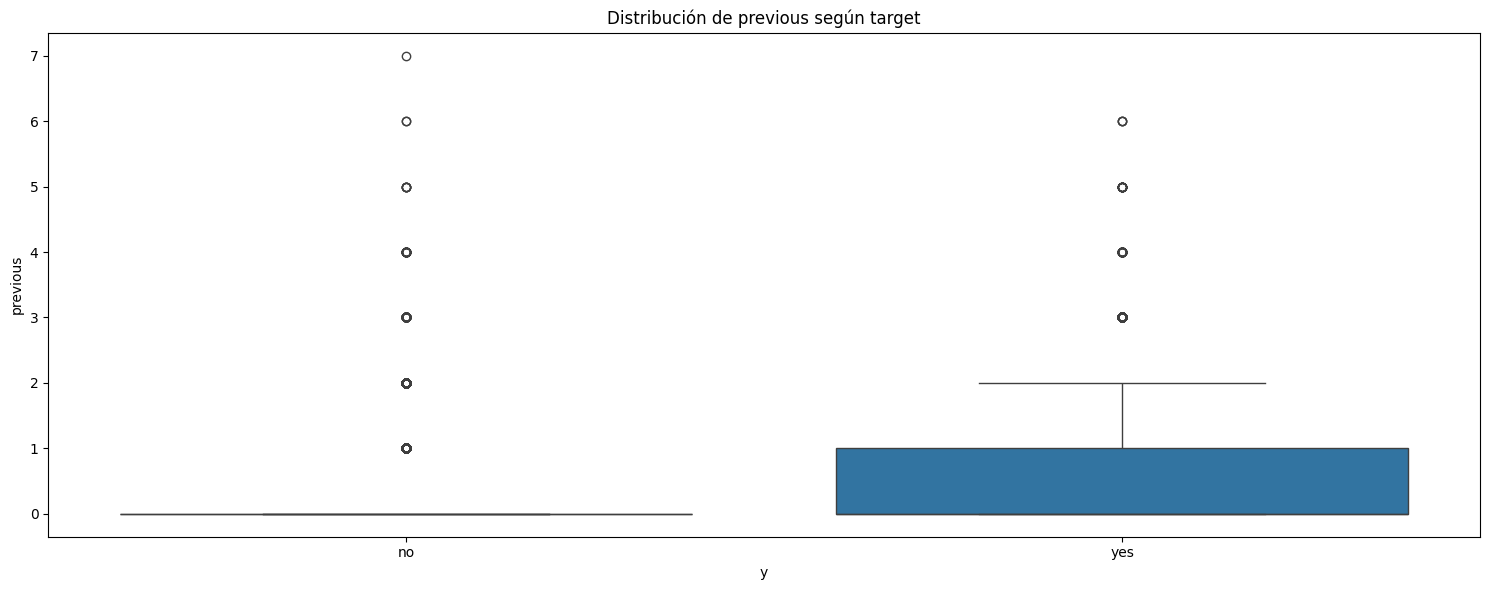

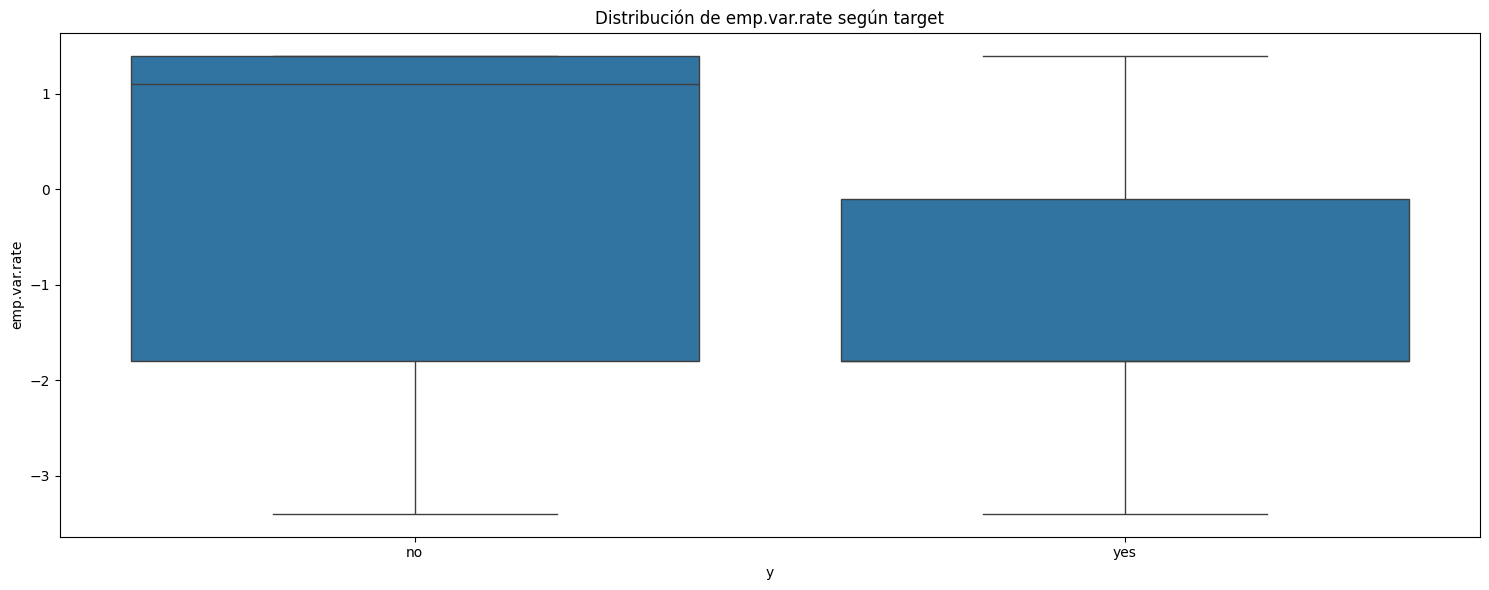

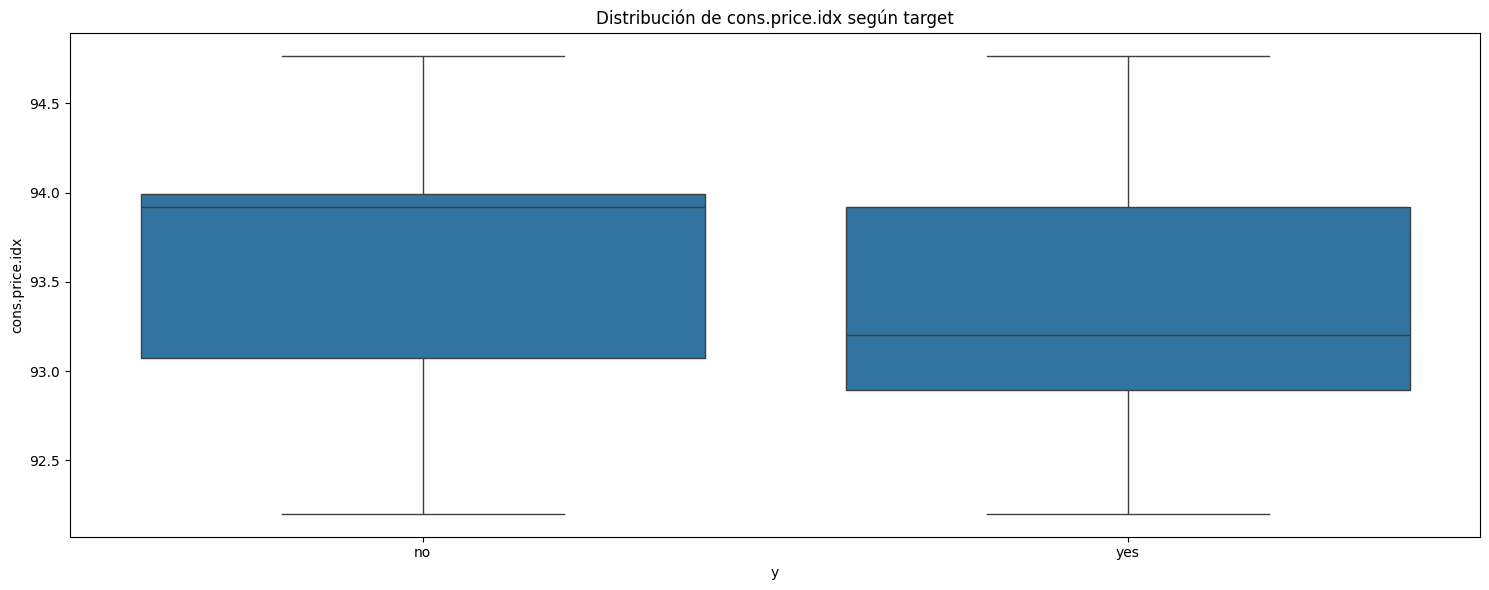

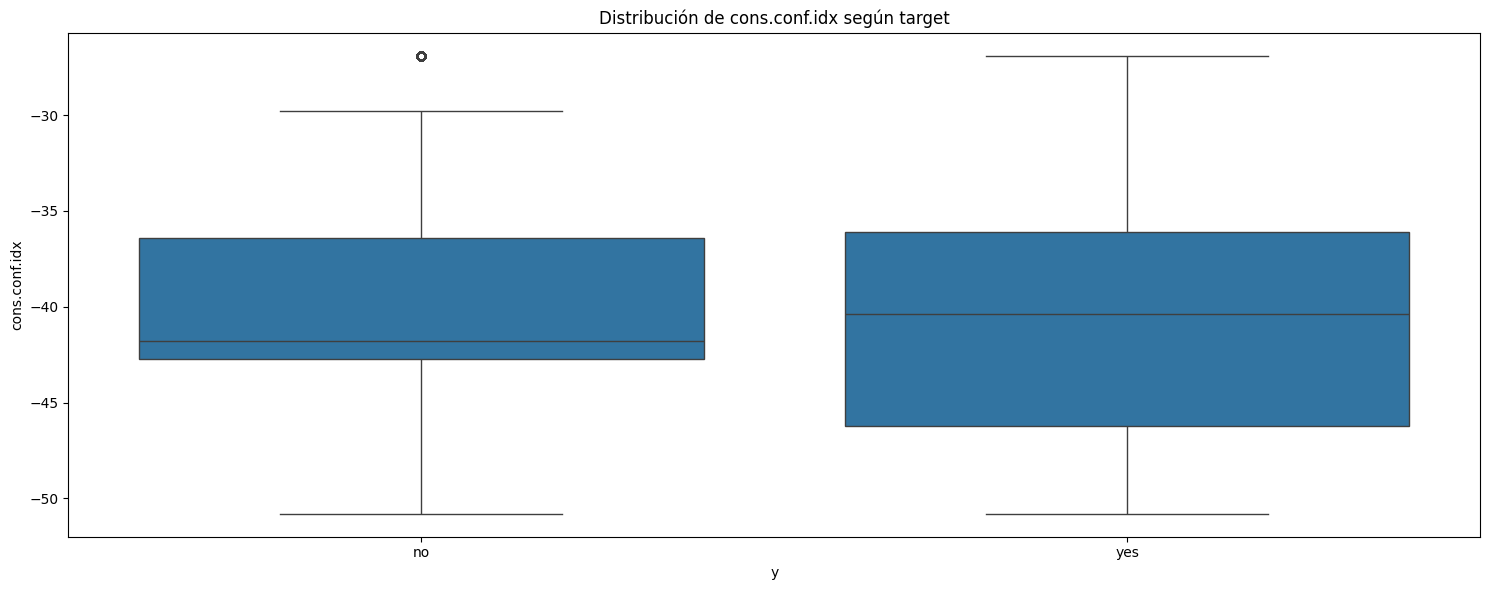

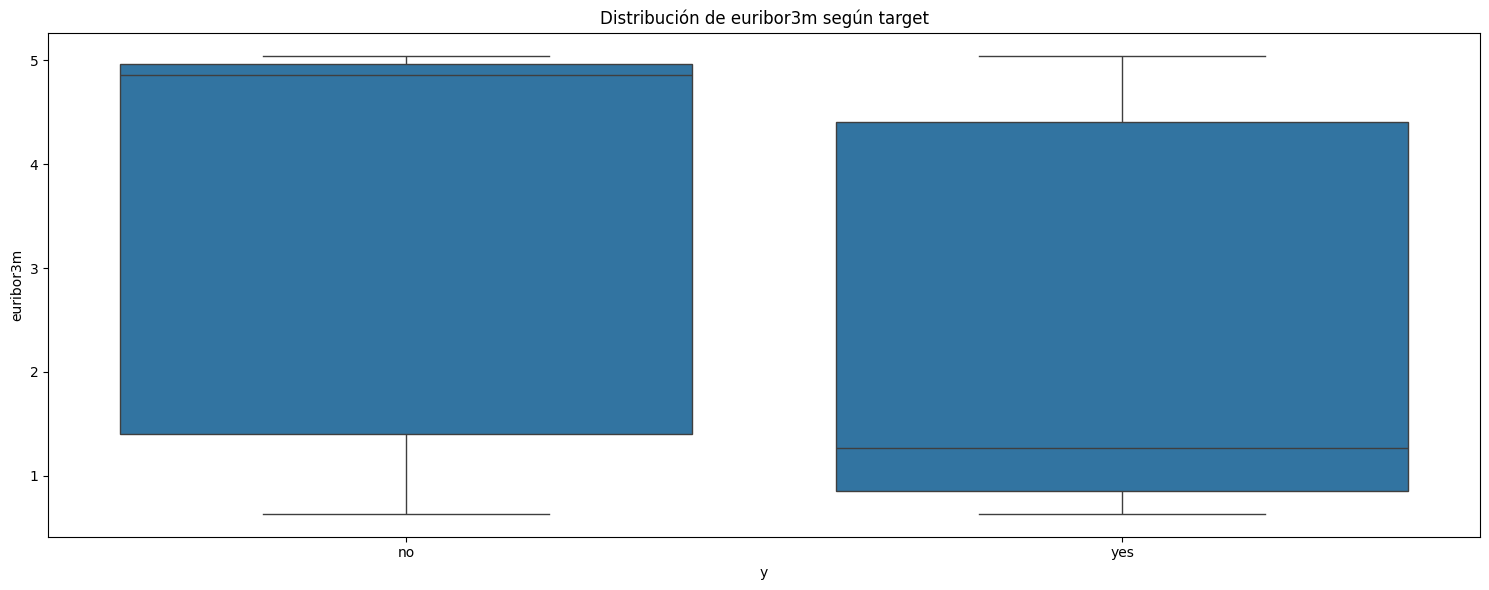

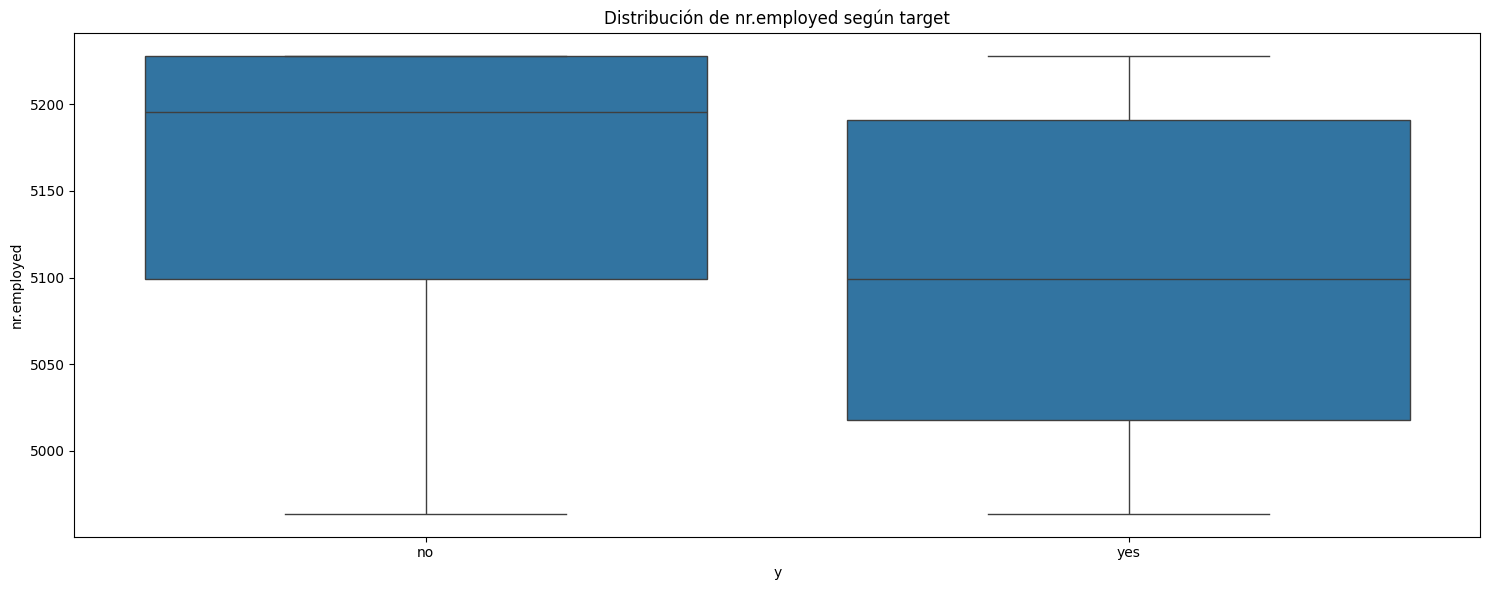

In [207]:
numeric_cols = ["age", "duration", "campaign","pdays", "previous","emp.var.rate", "cons.price.idx","cons.conf.idx", "euribor3m", "nr.employed"]

for columna in numeric_cols:
    plt.figure(figsize=(15,6))
    sns.boxplot(data=df, x='y', y=columna)
    plt.title(f"Distribución de {columna} según target")
    plt.tight_layout()
    plt.show()

### **ANÁLISIS MULTIVARIANTE**


#### **Análisis categórico-categórico**

#### Factorizaciuón:


In [208]:
df_factorize = df.copy()

In [209]:
df_factorize['default_y'] = pd.factorize(df['default'])[0]
df_factorize['matrial_y'] = pd.factorize(df['marital'])[0]
df_factorize['job_y'] = pd.factorize(df['job'])[0]
df_factorize['ducation_y'] = pd.factorize(df['education'])[0]
df_factorize['housing_y'] = pd.factorize(df['housing'])[0]
df_factorize['loan_y'] = pd.factorize(df['loan'])[0]
df_factorize['contact_y'] = pd.factorize(df['contact'])[0]
df_factorize['poutcome_y'] = pd.factorize(df['poutcome'])[0]
df_factorize['y_y'] = pd.factorize(df['y'])[0]

In [210]:
df_numerico = df_factorize.select_dtypes(include=['number'])

#### Mapas de correlación

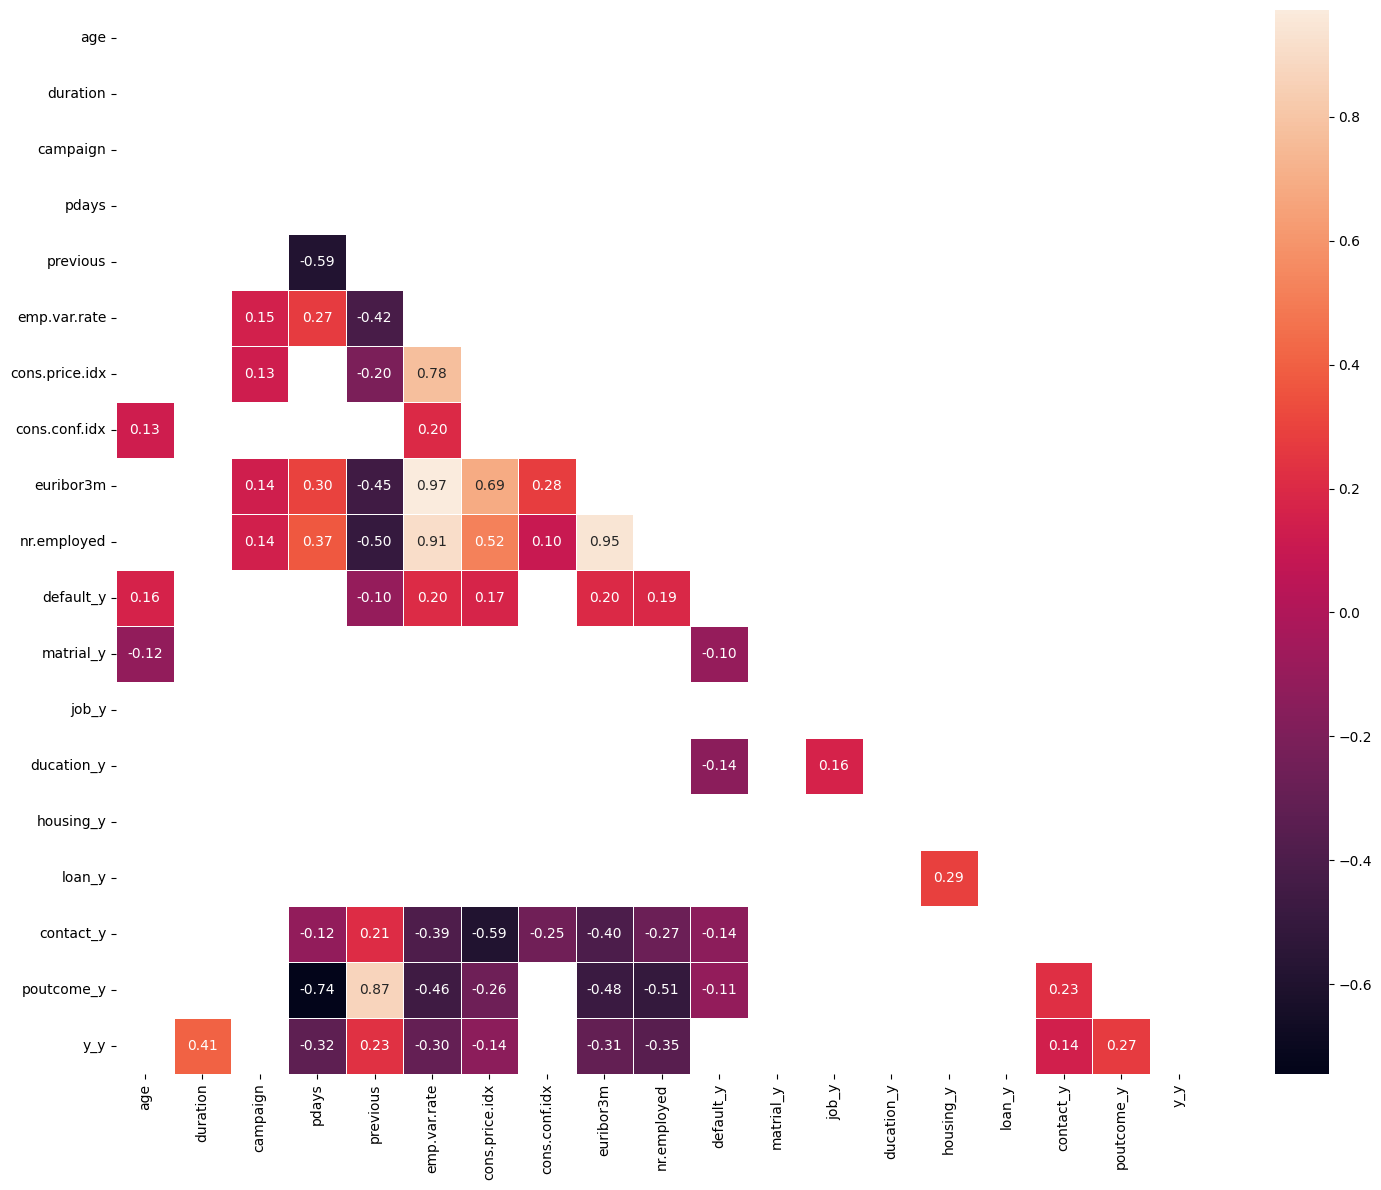

In [211]:
corr = df_numerico.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

**Conclusiones:**
> * Elimino las siguientes columnas:

In [212]:
df_num_dos = df_numerico.drop(columns=['default_y','poutcome_y','emp.var.rate','nr.employed','cons.price.idx'])
df_num_dos


,age,duration,campaign,pdays,previous,cons.conf.idx,euribor3m,matrial_y,job_y,ducation_y,housing_y,loan_y,contact_y,y_y
0,56,261,1,999,0,-36.4,4.857,0,0,0,0,0,0,0
1,57,149,1,999,0,-36.4,4.857,0,1,1,0,0,0,0
2,37,226,1,999,0,-36.4,4.857,0,1,1,1,0,0,0
3,40,151,1,999,0,-36.4,4.857,0,2,2,0,0,0,0
4,56,307,1,999,0,-36.4,4.857,0,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-50.8,1.028,0,5,4,1,0,1,1
41184,46,383,1,999,0,-50.8,1.028,0,3,4,0,0,1,0
41185,56,189,2,999,0,-50.8,1.028,0,5,6,1,0,1,0
41186,44,442,1,999,0,-50.8,1.028,0,4,4,0,0,1,1


* **Segundo heatmap para observas las correlaciones:**

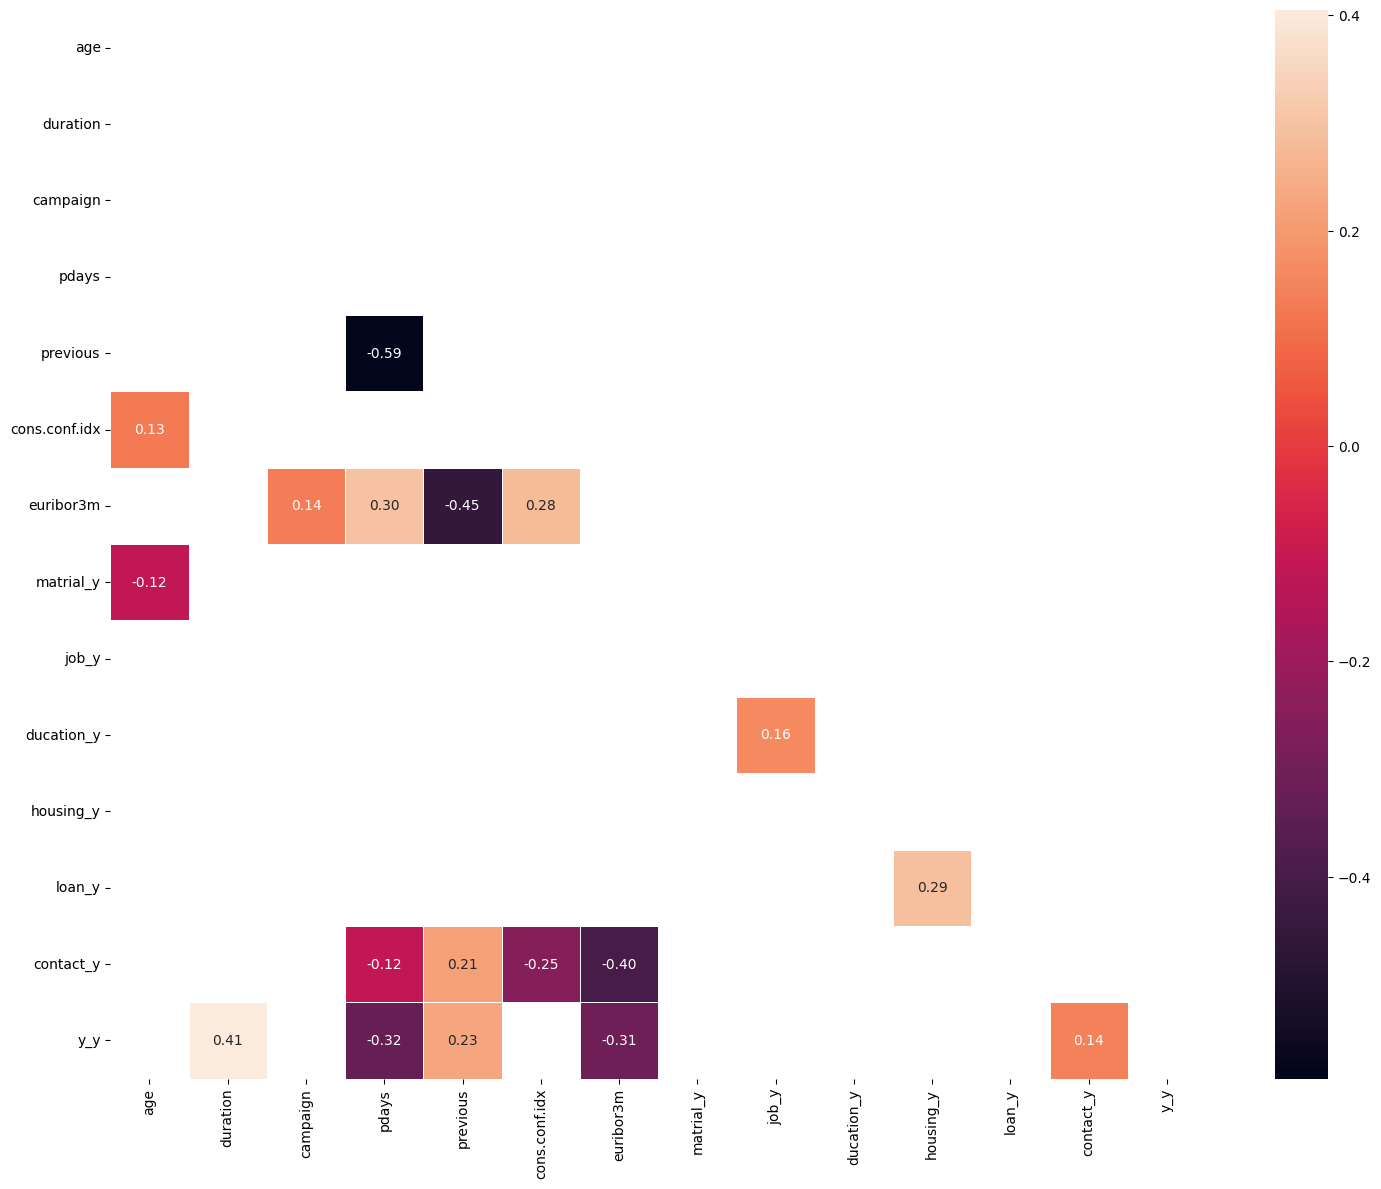

In [213]:
corr = df_num_dos.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

* **Conclusión final de la eliminación de columnas:**


In [214]:
df_num_dos.drop(columns=['previous'])

,age,duration,campaign,pdays,cons.conf.idx,euribor3m,matrial_y,job_y,ducation_y,housing_y,loan_y,contact_y,y_y
0,56,261,1,999,-36.4,4.857,0,0,0,0,0,0,0
1,57,149,1,999,-36.4,4.857,0,1,1,0,0,0,0
2,37,226,1,999,-36.4,4.857,0,1,1,1,0,0,0
3,40,151,1,999,-36.4,4.857,0,2,2,0,0,0,0
4,56,307,1,999,-36.4,4.857,0,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,-50.8,1.028,0,5,4,1,0,1,1
41184,46,383,1,999,-50.8,1.028,0,3,4,0,0,1,0
41185,56,189,2,999,-50.8,1.028,0,5,6,1,0,1,0
41186,44,442,1,999,-50.8,1.028,0,4,4,0,0,1,1


In [215]:
# Elimino columns de df orginial
df_droping = df.drop(columns=['previous', 'default','poutcome','emp.var.rate','nr.employed','cons.price.idx','euribor3m'])


In [216]:
# Columnas escogidas para el modelo de entrenamiento
df_droping.columns

Index(['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'cons.conf.idx', 'y'],
      dtype='object')

## PASO 5: **SPLIT DATA: train & test**

In [217]:
X = df_droping.drop("y", axis=1)
y = df_droping[ "y"]

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

In [218]:
X_train

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,cons.conf.idx
6707,35,blue-collar,divorced,basic.4y,yes,yes,telephone,may,wed,433,3,999,-36.4
38289,37,technician,married,university.degree,yes,no,cellular,oct,wed,364,1,999,-26.9
25861,34,admin.,married,university.degree,yes,no,cellular,nov,wed,174,1,999,-42.0
20623,33,admin.,single,university.degree,no,no,cellular,aug,wed,159,1,999,-36.1
27944,32,admin.,single,university.degree,unknown,unknown,cellular,mar,mon,77,3,999,-50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5295,41,self-employed,married,university.degree,yes,no,telephone,may,fri,150,6,999,-36.4
1727,33,technician,married,professional.course,no,no,telephone,may,fri,205,1,999,-36.4
35663,37,admin.,divorced,university.degree,yes,no,cellular,may,mon,442,1,999,-46.2
25728,45,admin.,married,high.school,yes,no,cellular,nov,wed,90,1,999,-42.0


In [219]:
X_train.columns 

Index(['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'cons.conf.idx'],
      dtype='object')

In [220]:
df_droping.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            41176 non-null  int64  
 1   job            41176 non-null  object 
 2   marital        41176 non-null  object 
 3   education      41176 non-null  object 
 4   housing        41176 non-null  object 
 5   loan           41176 non-null  object 
 6   contact        41176 non-null  object 
 7   month          41176 non-null  object 
 8   day_of_week    41176 non-null  object 
 9   duration       41176 non-null  int64  
 10  campaign       41176 non-null  int64  
 11  pdays          41176 non-null  int64  
 12  cons.conf.idx  41176 non-null  float64
 13  y              41176 non-null  object 
dtypes: float64(1), int64(4), object(9)
memory usage: 4.7+ MB


In [221]:
df_droping.columns

Index(['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'cons.conf.idx', 'y'],
      dtype='object')

In [ ]:
# Genero una lista con los nombres de las columnas categóricas
cat_variables = ['job', 'marital','education', 'housing', 'loan', 'contact','month', 'day_of_week']

# Creamos la instancia del encoder
onehot_encoder = OneHotEncoder(sparse_output=False, drop='if_binary')

# Entrenamos el encoder con los datos de entrenamiento (ajustamos)
onehot_encoder.fit_transform(X_train[cat_variables])

# Aplicamos el encoder en el conjunto de entrenamiento: X_train
X_train_cat_ohe = onehot_encoder.transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe,
                               index=X_train.index,
                               columns=onehot_encoder.get_feature_names_out(cat_variables))

# Aplicamos el encoder en el conjunto de test: X_test
X_test_cat_ohe = onehot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe,
                              index=X_test.index,
                              columns=onehot_encoder.get_feature_names_out(cat_variables))

X_train_cat_ohe.head()o


,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
6707,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
38289,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
25861,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
20623,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
27944,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [223]:
X_train_cat_ohe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32940 entries, 6707 to 28956
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   job_admin.                     32940 non-null  float64
 1   job_blue-collar                32940 non-null  float64
 2   job_entrepreneur               32940 non-null  float64
 3   job_housemaid                  32940 non-null  float64
 4   job_management                 32940 non-null  float64
 5   job_retired                    32940 non-null  float64
 6   job_self-employed              32940 non-null  float64
 7   job_services                   32940 non-null  float64
 8   job_student                    32940 non-null  float64
 9   job_technician                 32940 non-null  float64
 10  job_unemployed                 32940 non-null  float64
 11  job_unknown                    32940 non-null  float64
 12  marital_divorced               32940 non-null  f

In [224]:
X_train_cat_ohe.drop(['job_admin.','education_basic.4y','month_apr','day_of_week_tue','housing_no','loan_no'], axis=1, inplace=True)


In [225]:
X_train_cat_ohe

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_wed
6707,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
38289,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
25861,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
20623,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
27944,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5295,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
35663,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
25728,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [226]:
X_test_cat_ohe.drop(['job_admin.','education_basic.4y','month_apr','day_of_weedk','housing_no','loan_no'], axis=1, inplace=True)


KeyError: "['day_of_weedk'] not found in axis"

In [ ]:
X_test_cat_ohe

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,...,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
6686,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
28748,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18255,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
32003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32752,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28448,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
38865,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
25516,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
28454,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## **LABEL ENCODER --> no en este proyecto poruqe es Regresion logistica = Clasificacion**

In [ ]:
# # 0. Creamos copias de los conjuntos de entrenamiento: X_train | X_test
# X_train_cat_le = X_train.copy()
# X_test_cat_le = X_test.copy()

# # 1. Creamos las instancias del encoder
# label_encoder_marital = LabelEncoder()
# # 2. Entrenamos los encoders con los datos de entrenamiento (ajustamos) fit
# label_encoder_marital.fit(X_train['marital'])
# # 3. Aplicamos el encoder en ambos conjuntos (entrenamiento y test) transform
# X_train_cat_le['marital_le'] = label_encoder_marital.transform(X_train['marital'])
# X_test_cat_le['marital_le'] = label_encoder_marital.transform(X_test['marital'])


# # 1. Creamos las instancias del encoder
# label_encoder_education = LabelEncoder()
# # 2. Entrenamos los encoders con los datos de entrenamiento (ajustamos) utilizamos: fit()
# label_encoder_education.fit(X_train['education'])
# # 3. Aplicamos el encoder en ambos conjuntos (entrenamiento y test) transform
# X_train_cat_le['education_le'] = label_encoder_education.transform(X_train['education'])  # 3.1 train
# X_test_cat_le['education_le'] = label_encoder_education.transform(X_test['education'])  # 3.2 test

# # 1. Creamos las instancias del encoder
# label_encoder_job = LabelEncoder()
# # 2. Entrenamos los encoders con los datos de entrenamiento (ajustamos) utilizamos: fit()
# label_encoder_job.fit(X_train['job'])
# # 3. Aplicamos el encoder en ambos conjuntos (entrenamiento y test) transform
# X_train_cat_le['job_le'] = label_encoder_job.transform(X_train['job'])  # 3.1 train
# X_test_cat_le['job_le'] = label_encoder_job.transform(X_test['job'])  # 3.2 test

# # 1. Creamos las instancias del encoder
# label_encoder_housing = LabelEncoder()
# # 2. Entrenamos los encoders con los datos de entrenamiento (ajustamos) utilizamos: fit()
# label_encoder_housing.fit(X_train['housing'])
# # 3. Aplicamos el encoder en ambos conjuntos (entrenamiento y test) transform
# X_train_cat_le['housing_le'] = label_encoder_housing.transform(X_train['housing'])  # 3.1 train
# X_test_cat_le['housing_le'] = label_encoder_housing.transform(X_test['housing'])  # 3.2 test

# # 1. Creamos las instancias del encoder
# label_encoder_loan = LabelEncoder()
# # 2. Entrenamos los encoders con los datos de entrenamiento (ajustamos) utilizamos: fit()
# label_encoder_loan.fit(X_train['loan'])
# # 3. Aplicamos el encoder en ambos conjuntos (entrenamiento y test) transform
# X_train_cat_le['loan_le'] = label_encoder_loan.transform(X_train['loan'])  # 3.1 train
# X_test_cat_le['loan_le'] = label_encoder_loan.transform(X_test['loan'])  # 3.2 test

# # 1. Creamos las instancias del encoder
# label_encoder_month = LabelEncoder()
# # 2. Entrenamos los encoders con los datos de entrenamiento (ajustamos) utilizamos: fit()
# label_encoder_month.fit(X_train['month'])
# # 3. Aplicamos el encoder en ambos conjuntos (entrenamiento y test) transform
# X_train_cat_le['month_le'] = label_encoder_month.transform(X_train['month'])  # 3.1 train
# X_test_cat_le['month_le'] = label_encoder_month.transform(X_test['month'])  # 3.2 test

# # 1. Creamos las instancias del encoder
# label_encoder_contact = LabelEncoder()
# # 2. Entrenamos los encoders con los datos de entrenamiento (ajustamos) utilizamos: fit()
# label_encoder_contact.fit(X_train['contact'])
# # 3. Aplicamos el encoder en ambos conjuntos (entrenamiento y test) transform
# X_train_cat_le['contact_le'] = label_encoder_contact.transform(X_train['contact'])  # 3.1 train
# X_test_cat_le['contact_le'] = label_encoder_contact.transform(X_test['contact'])  # 3.2 test

# # 1. Creamos las instancias del encoder
# label_encoder_day_of_week = LabelEncoder()
# # 2. Entrenamos los encoders con los datos de entrenamiento (ajustamos) utilizamos: fit()
# label_encoder_day_of_week.fit(X_train['day_of_week'])
# # 3. Aplicamos el encoder en ambos conjuntos (entrenamiento y test) transform
# X_train_cat_le['day_of_week_le'] = label_encoder_day_of_week.transform(X_train['day_of_week'])  # 3.1 train
# X_test_cat_le['day_of_week_le'] = label_encoder_day_of_week.transform(X_test['day_of_week'])  # 3.2 test


# X_train_cat_le.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,...,pdays,cons.conf.idx,marital_le,education_le,job_le,housing_le,loan_le,month_le,contact_le,day_of_week_le
6707,35,blue-collar,divorced,basic.4y,yes,yes,telephone,may,wed,433,...,999,-36.4,0,0,1,2,2,6,1,4
38289,37,technician,married,university.degree,yes,no,cellular,oct,wed,364,...,999,-26.9,1,6,9,2,0,8,0,4
25861,34,admin.,married,university.degree,yes,no,cellular,nov,wed,174,...,999,-42.0,1,6,0,2,0,7,0,4
20623,33,admin.,single,university.degree,no,no,cellular,aug,wed,159,...,999,-36.1,2,6,0,0,0,1,0,4
27944,32,admin.,single,university.degree,unknown,unknown,cellular,mar,mon,77,...,999,-50.0,2,6,0,1,1,5,0,1


conh label encoder 

## **Guardado de data**

In [ ]:
# Guardamos utilizando Pickle (que nos permite guardar objetos de Python)
with open('../models/logistic-regression-label-encoder.pkl', 'wb') as file:
    pickle.dump(onehot_encoder, file)


### **ESCALADO DE NORMALIZACIÓN**

In [ ]:
X_test_cat_ohe.columns

Index(['job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.4y', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'housing_no', 'housing_unknown', 'housing_yes',
       'loan_no', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_apr',
       'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri',
       'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed'],
      dtype='object')

In [ ]:
# Realizar el escalando con el dataset dividido (ahora lo estamos haciendo completo)
norm_scaler = StandardScaler()  # Instancia de: from sklearn.preprocessing import StandardScaler

num_variables = ['job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.4y', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'housing_no', 'housing_unknown', 'housing_yes',
       'loan_no', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_apr',
       'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri',
       'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed']
norm_features = norm_scaler.fit_transform(df[num_variables])

df_norm = pd.DataFrame(norm_features,
                       index=df.index,
                       columns=num_variables)
df_norm.head()

KeyError: "None of [Index(['job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',\n       'job_management', 'job_retired', 'job_self-employed', 'job_services',\n       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',\n       'marital_divorced', 'marital_married', 'marital_single',\n       'marital_unknown', 'education_basic.4y', 'education_basic.6y',\n       'education_basic.9y', 'education_high.school', 'education_illiterate',\n       'education_professional.course', 'education_university.degree',\n       'education_unknown', 'housing_no', 'housing_unknown', 'housing_yes',\n       'loan_no', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_apr',\n       'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar',\n       'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri',\n       'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',\n       'day_of_week_wed'],\n      dtype='object')] are in the [columns]"

### **Generar modelo: ENTRENAMIENTO DEL MODELO CON LOS DATOS ESCALADOS**

In [ ]:
# Genera el modelo: genera una instancia de la clase LogisticRegression / Creando el modelo (vacío)
model = LogisticRegression(random_state=18)

# Entrena
model.fit(X_train_cat_le_scaled, y_train)

### **PREDICCION DEL MODELO**

In [ ]:
# pREDECIR EL CONJUNTO DE DATOS TEST
y_pred = model.predict(X_test_cat_le_scaled)
y_pred